In [1]:
import cv2        # Untuk pemrosesan gambar (Resizing, dll.)
import os         # Untuk interaksi dengan sistem file (path, folder)
import numpy as np  # Untuk operasi array (digunakan oleh OpenCV dan ML)
from matplotlib import pyplot as plt # Untuk menampilkan gambar dan grafik

In [ ]:
def resize_and_save_images(input_dir, output_dir, target_size=(400, 400)):
    """
    Mengubah ukuran semua gambar di input_dir ke target_size 
    dan menyimpannya di output_dir.
    """
    
    # Membuat folder output jika belum ada
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Folder output '{output_dir}' dibuat.")

    # Mendapatkan daftar semua file gambar
    image_files = [f for f in os.listdir(input_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"Memulai resizing pada {len(image_files)} gambar...")
    
    # Loop melalui setiap file gambar
    for i, filename in enumerate(image_files):
        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, filename)

        # Muat Gambar (Load Image)
        img = cv2.imread(input_path)
        
        if img is None:
            print(f"Peringatan: Gagal memuat gambar: {filename}")
            continue

        # Resizing Gambar
        resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # Simpan Gambar yang telah diubah ukurannya
        cv2.imwrite(output_path, resized_img)
        
        # Tampilkan kemajuan
        if (i + 1) % 100 == 0 or (i + 1) == len(image_files):
            print(f"Telah memproses {i + 1}/{len(image_files)} gambar.")

    print(f"\nSelesai! Gambar yang telah diubah ukurannya disimpan di: {output_dir}")
    print(f"Dimensi baru: {target_size[0]} x {target_size[1]} piksel.")
    
    # Tampilkan contoh gambar (Opsional)
    if len(image_files) > 0:
        plt.figure(figsize=(10, 5))
        
        # Gambar Asli
        original_img = cv2.imread(os.path.join(input_dir, image_files[0]))
        plt.subplot(1, 2, 1)
        plt.title(f"Original ({original_img.shape[1]}x{original_img.shape[0]})")
        plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        
        # Gambar Setelah Resizing
        resized_img_display = cv2.imread(output_path)
        plt.subplot(1, 2, 2)
        plt.title(f"Resized ({resized_img_display.shape[1]}x{resized_img_display.shape[0]})")
        plt.imshow(cv2.cvtColor(resized_img_display, cv2.COLOR_BGR2RGB))
        plt.show()

Folder output 'Resizing_dataset/T_resizing' dibuat.
Memulai resizing pada 40 gambar...
Telah memproses 40/40 gambar.

Selesai! Gambar yang telah diubah ukurannya disimpan di: Resizing_dataset/T_resizing
Dimensi baru: 400 x 400 piksel.


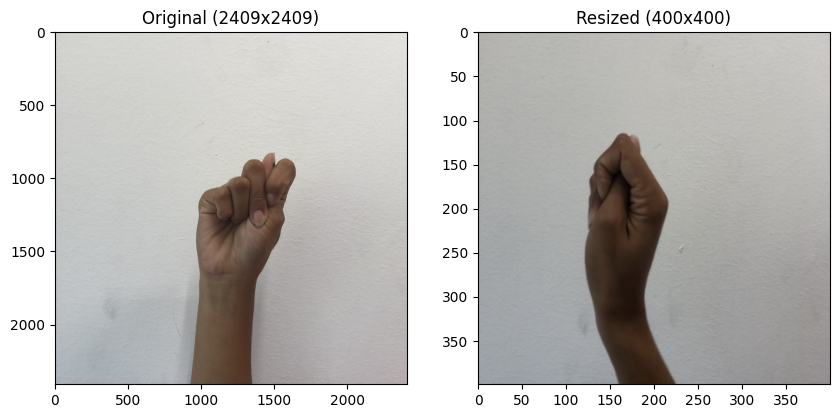

In [30]:
# --- PENGGUNAAN KODE ---

# Konfigurasi Path dan Dimensi
INPUT_FOLDER = "DATASET/T" 
OUTPUT_FOLDER = "Resizing_dataset/T_resizing"
TARGET_DIMENSIONS = (400, 400) 

# Panggil fungsi
resize_and_save_images(INPUT_FOLDER, OUTPUT_FOLDER, TARGET_DIMENSIONS)